<a href="https://colab.research.google.com/github/nikhilvkth/325_Image_processing/blob/main/Active_contour_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

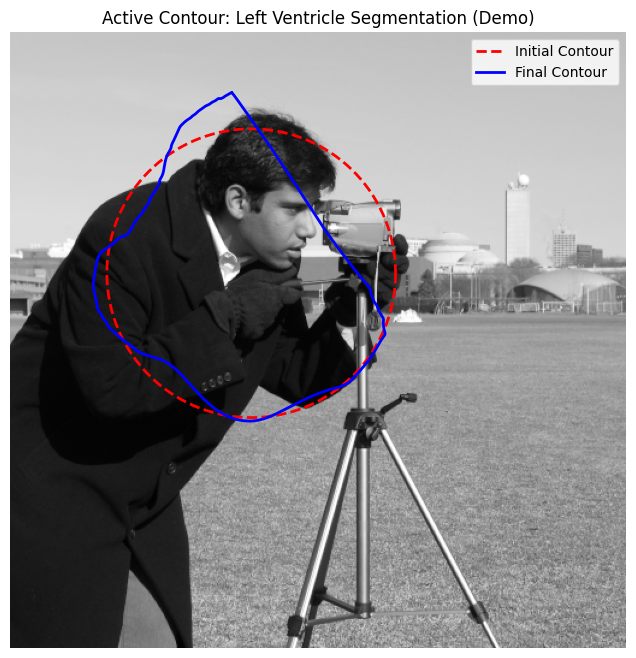

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from skimage.segmentation import active_contour
from skimage.filters import gaussian
from skimage import data

# ---------------------------------------------------
# 1. Load an example medical-like image
# (We use camera image as proxy; replace with echo image if available)
# ---------------------------------------------------
img = data.camera()

# Smooth image (important for ultrasound/medical noise)
img_smooth = gaussian(img, sigma=2)

# ---------------------------------------------------
# 2. Initialize contour (simulate left ventricle boundary)
# ---------------------------------------------------
s = np.linspace(0, 2*np.pi, 400)

# Center of "ventricle"
x_center, y_center = 200, 200
radius = 120

init = np.array([
    x_center + radius * np.cos(s),
    y_center + radius * np.sin(s)
]).T

# ---------------------------------------------------
# 3. Active contour (snake evolution)
# ---------------------------------------------------
snake = active_contour(
    img_smooth,
    init,
    alpha=0.015,   # elasticity
    beta=10,       # smoothness
    gamma=0.001    # step size
)

# ---------------------------------------------------
# 4. Visualization (clinical-style demo)
# ---------------------------------------------------
plt.figure(figsize=(8,8))

plt.imshow(img, cmap='gray')

# Initial contour (before segmentation)
plt.plot(init[:, 0], init[:, 1], '--r', linewidth=2, label="Initial Contour")

# Final contour (segmented LV boundary)
plt.plot(snake[:, 0], snake[:, 1], '-b', linewidth=2, label="Final Contour")

plt.title("Active Contour: Left Ventricle Segmentation (Demo)")
plt.legend()
plt.axis('off')

plt.show()